In [3]:
import numpy as np
import matplotlib.pyplot as plt
from utils_w3 import *
import copy
import math

In [5]:
#loading dataset
x_train,y_train = load_data("data/ex2data1.txt")

In [7]:
print('first 5 elements in x train :', x_train[:5])
print(type(x_train))

first 5 elements in x train : [[34.62365962 78.02469282]
 [30.28671077 43.89499752]
 [35.84740877 72.90219803]
 [60.18259939 86.3085521 ]
 [79.03273605 75.34437644]]
<class 'numpy.ndarray'>


In [8]:
print('first 5 elements in y train :', y_train[:5])
print(type(y_train))

first 5 elements in y train : [0. 0. 0. 1. 1.]
<class 'numpy.ndarray'>


In [10]:
print(x_train.shape)
print(y_train.shape)
print(len(y_train))

(100, 2)
(100,)
100


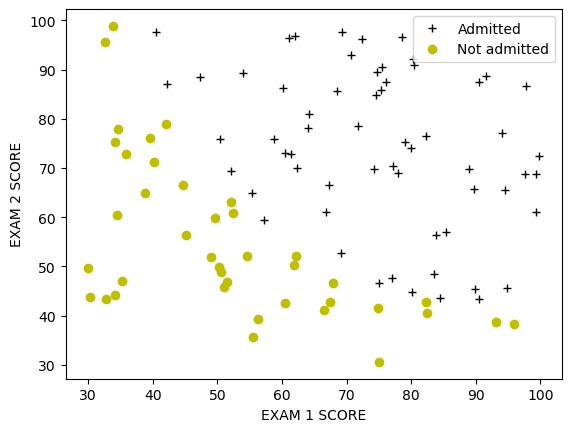

In [12]:
#plotting

plot_data(x_train,y_train[:], pos_label="Admitted", neg_label="Not admitted")
plt.ylabel('EXAM 2 SCORE')
plt.xlabel('EXAM 1 SCORE')
plt.legend(loc='upper right')
plt.show()

In [13]:
#SIGMOID FUNCTION:

def sigmoid(z):
    g = 1 / (1 + np.exp(-z))
    return g

In [15]:
#TESTING

print('sigmoid(0) = ', str(sigmoid(0)))

sigmoid(0) =  0.5


In [26]:
#TESTING WITH MATRIXS

print('sigmoid([-1,0,1,2]) = ', sigmoid(np.array([-1,0,1,2])))

#UNIT TEST
from public_tests_w3 import *
sigmoid_test(sigmoid)

sigmoid([-1,0,1,2]) =  [0.26894142 0.5        0.73105858 0.88079708]
All tests passed!


In [31]:
#Cost function for logistic regression

def compute_cost( x,y,w,b,lambda_ = 1):
    m, n = x.shape
    total_cost = 0
    for i in range (m):
        z_i = np.dot(x[i], w) + b
        f_wb_i = sigmoid(z_i)
        loss = -y[i] * np.log(f_wb_i) - (1-y[i]) * np.log(1 - f_wb_i)
        total_cost += loss
    total_cost = total_cost / m
    return total_cost
    

In [37]:
m, n = x_train.shape

initial_w = np.zeros(n)
initial_b = 0

cost =  compute_cost(x_train,y_train, initial_w, initial_b)
print('cost a w (zeros)', cost)

cost a w (zeros) 0.6931471805599458


In [39]:
# Compute and display cost with non-zero w
test_w = np.array([0.2, 0.2])
test_b = -24.
cost = compute_cost(x_train, y_train, test_w, test_b)

print('Cost at test w,b: {:.3f}'.format(cost))


# UNIT TESTS
compute_cost_test(compute_cost)

Cost at test w,b: 0.218
All tests passed!


In [45]:
#Gradient for logistic regression

def compute_gradient(x,y,w,b,lambda_ =None):
    m,n = x.shape
    dj_dw = np.zeros(w.shape)
    dj_db = 0
    for i in range(m):
        # 1. Calculate prediction using sigmoid
        f_wb_i = sigmoid(np.dot(x[i], w) + b)
        error_i = f_wb_i - y[i]
        
        # 2. Accumulate the raw bias error
        dj_db += error_i
        
        # 3. Accumulate the weight errors feature by feature
        for j in range(n):
            dj_dw[j] += error_i * x[i][j]
            
    # 4. Divide by m completely outside the loops
    dj_db = dj_db / m
    dj_dw = dj_dw / m
    return dj_db, dj_dw

In [47]:
# Compute and display gradient with w = zeroes
initial_w = np.zeros(n)
initial_b = 0.

dj_db, dj_dw = compute_gradient(x_train, y_train, initial_w, initial_b)
print(f'dj_db at initial w (zeros):{dj_db}' )
print(f'dj_dw at initial w (zeros):{dj_dw.tolist()}' )

dj_db at initial w (zeros):-0.1
dj_dw at initial w (zeros):[-12.00921658929115, -11.262842205513591]


In [48]:
# Compute and display cost and gradient with non-zero w
test_w = np.array([ 0.2, -0.5])
test_b = -24
dj_db, dj_dw  = compute_gradient(x_train, y_train, test_w, test_b)

print('dj_db at test_w:', dj_db)
print('dj_dw at test_w:', dj_dw.tolist())

# UNIT TESTS    
compute_gradient_test(compute_gradient)

dj_db at test_w: -0.5999999999991071
dj_dw at test_w: [-44.831353617873795, -44.37384124953978]
All tests passed!


In [66]:
def gradient_descent(x, y, w, b, compute_cost, gradient_function, alpha, iterations, lambda_):
    for i in range(iterations):
        # 1. Compute the slopes of the multi-feature error mountain
        dj_db, dj_dw = gradient_function(x, y, w, b, lambda_)
        
        # 2. Vector update parameters simultaneously
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        
    return w, b

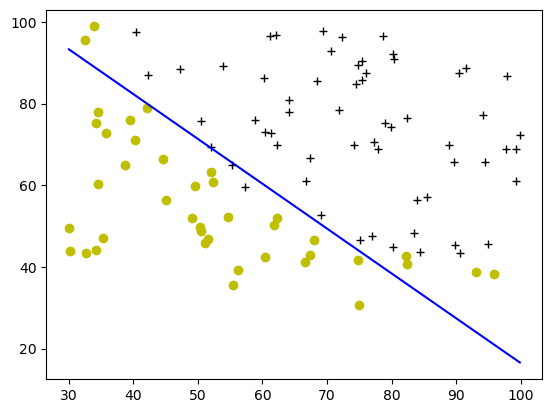

In [69]:

plot_decision_boundary(w, b, x_train, y_train)

In [72]:
#prediction

def predict(x, w, b):
    m,n = x.shape
    p = np.zeros(m)
    for i in range(m):
        z = np.dot(x[i],w) + b
        f_wb = sigmoid(z)
       
    
        if f_wb >= 0.5:
                p[i] = 1
        else:
            p[i] = 0
    return p

In [73]:
# Test your predict code
np.random.seed(1)
tmp_w = np.random.randn(2)
tmp_b = 0.3    
tmp_x = np.random.randn(4, 2) - 0.5

tmp_p = predict(tmp_x, tmp_w, tmp_b)
print(f'Output of predict: shape {tmp_p.shape}, value {tmp_p}')

# UNIT TESTS        
predict_test(predict)

Output of predict: shape (4,), value [0. 1. 1. 1.]
All tests passed!


In [75]:
#Compute accuracy on our training set
p = predict(x_train, w,b)
print('Train Accuracy: %f'%(np.mean(p == y_train) * 100))

Train Accuracy: 92.000000
